# Correlation Analysis

#### The Correlation Coefficient

The **correlation coefficient** (Pearson's r) measures how strongly and in what direction two variables are **linearly** related. Its value always lies between **-1** and **+1**.

- **r > 0** → positive (direct) relationship: as one variable increases, the other tends to increase  
- **r < 0** → negative (inverse) relationship: as one variable increases, the other tends to decrease  
- **r ≈ 0** → very weak or no linear relationship  

The closer |r| is to 1, the stronger the linear relationship. The closer it is to 0, the weaker the linear association.

**Formula**:

$$
r = \frac{\text{Cov}(X,Y)}{\text{std}(X) \cdot \text{std}(Y)}
$$

Where:
- $\text{Cov}(X,Y)$ = covariance between X and Y  
- $\text{std}(X)$ = standard deviation of X  
- $\text{std}(Y)$ = standard deviation of Y  

**Important note**:  
Two randomly generated sets of data (with no real relationship) will typically have a correlation coefficient **close to 0**.

#### Correlation vs Covariance

Correlation is simply a normalised form of covariance. They are otherwise the same and are often used semi-interchangeably.



In [62]:
import numpy as np
import pandas as pd
import yfinance as yf
import scipy.stats as stats
import math
import warnings

# Silent futurewarnings
warnings.simplefilter(action='ignore', category=FutureWarning)

from matplotlib import pyplot as plt

#### Covariance is not that meaningful by itself

Consider two variables $X$ and $Y$ and we take the covariance of the two

In [63]:
X = np.random.randn(50)
Y = 2 * X + np.random.normal(0, 0.1, 50)

print("Covariance between X and Y:", np.cov(X, Y)[0, 1])

Covariance between X and Y: 2.1930039211726293


#### Why does correlation fall between -1 and +1?

The correlation coefficient normalizes the covariance using the standard deviations (or variances) of X and Y. This normalization puts the measure on a consistent **-1 to +1** scale, allowing us to meaningfully compare the strength and direction of linear relationships across different pairs of variables — regardless of their units or scales.

**Starting from the definition:**

$$
r = \frac{\text{Cov}(X,Y)}{\text{std}(X) \cdot \text{std}(Y)}
$$

We can rewrite this using **variances** instead of standard deviations (since $\text{std}(X) = \sqrt{\text{var}(X)}$ and $\text{std}(Y) = \sqrt{\text{var}(Y)}$):

$$
r = \frac{\text{Cov}(X,Y)}{\sqrt{\text{var}(X)} \cdot \sqrt{\text{var}(Y)}} = \frac{\text{Cov}(X,Y)}{\sqrt{\text{var}(X) \cdot \text{var}(Y)}}
$$

Another common (equivalent) way to express it uses covariance notation only:

$$
r = \frac{\text{Cov}(X,Y)}{\sqrt{\text{Cov}(X,X)} \cdot \sqrt{\text{Cov}(Y,Y)}}
$$

(since $\text{var}(X) = \text{Cov}(X,X)$ and $\text{var}(Y) = \text{Cov}(Y,Y)$ by definition)

This form highlights that correlation is essentially a **normalized covariance** — divided by the geometric mean of the variables' own variances. The denominator ensures the result is dimensionless and bounded between -1 and 1.

In [64]:
X = np.random.rand(50)
Y = 2 * X + 4

print("Covariance between X and Y:\n", np.cov(X, Y))
print("Correlation between X and Y:\n", np.corrcoef(X, Y))

Covariance between X and Y:
 [[0.09430066 0.18860132]
 [0.18860132 0.37720263]]
Correlation between X and Y:
 [[1. 1.]
 [1. 1.]]


#### Why do `np.cov()` and `np.corrcoef()` both return matrices?

The **covariance matrix** is a central object in statistics and data analysis.   When people talk about "the covariance between two variables X and Y", they are actually referring to **one single entry** in this matrix. For a dataset with **multiple variables** (columns), NumPy's `np.cov()` and `np.corrcoef()` return the full **covariance / correlation matrix** — not just a single number.

##### Key properties of the covariance matrix:

Suppose we have data with **p variables** (e.g., columns in a 2D array). Then `np.cov(data)` produces a **p × p** symmetric matrix where:

- **Diagonal elements** → variances of each variable  
  → $\text{Cov}(X_i, X_i) = \text{Var}(X_i)$

- **Off-diagonal elements** → covariances between different variables  
  → $\text{Cov}(X_i, X_j)$ for $i ≠ j$

- The matrix is always **symmetric**:  
  $\text{Cov}(X_i, X_j) = \text{Cov}(X_j, X_i)$

##### Example structure (for 3 variables $X$, $Y$, $Z$):

$$
\begin{bmatrix}
\text{Var}(X)    & \text{Cov}(X,Y) & \text{Cov}(X,Z) \\
\text{Cov}(Y,X)  & \text{Var}(Y)   & \text{Cov}(Y,Z) \\
\text{Cov}(Z,X)  & \text{Cov}(Z,Y) & \text{Var}(Z)
\end{bmatrix}
$$

Since the matrix is symmetric, the lower triangle mirrors the upper triangle.

##### Quick check in code:

```python
import numpy as np

# Example: 3 variables, 100 observations each
data = np.random.randn(100, 3)          # shape (n_samples, n_features)
cov_matrix = np.cov(data, rowvar=False) # or rowvar=True if rows are variables

print("Shape of covariance matrix:", cov_matrix.shape)     # → (3, 3)
print("Diagonal (variances):\n", np.diag(cov_matrix))
print("Is symmetric?", np.allclose(cov_matrix, cov_matrix.T))

In [65]:
cov_matrix = np.cov(X, Y)

# We need to manually set the degrees of freedom to 1 to get the sample variance, as numpy's cov function by default uses the population variance (ddof=0).
error = cov_matrix[0, 0] - X.var(ddof=1)
print("Error", error)

Error 1.3877787807814457e-17


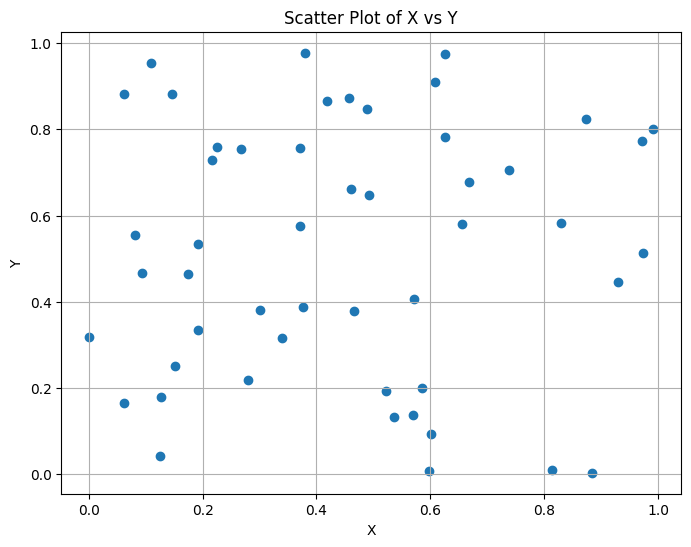

Correlation: 0.032785632809824626
Built-in Correlation: 0.032129920153628144


In [66]:
X = np.random.rand(50)
Y = np.random.rand(50)
plt.figure(figsize=(8, 6))
plt.scatter(X, Y)
plt.title("Scatter Plot of X vs Y")
plt.xlabel("X")
plt.ylabel("Y")
plt.grid()
plt.show()

# Taking the relevant value from the matrix returned by np.cov
print("Correlation: "+str(np.cov(X, Y)[0, 1] / (np.std(X) * np.std(Y))))

# Let us also use the built-in function to calculate the correlation coefficient
print("Built-in Correlation: "+str(np.corrcoef(X, Y)[0, 1]))

With that in mind, let us now consider how two correlated set of data would look like

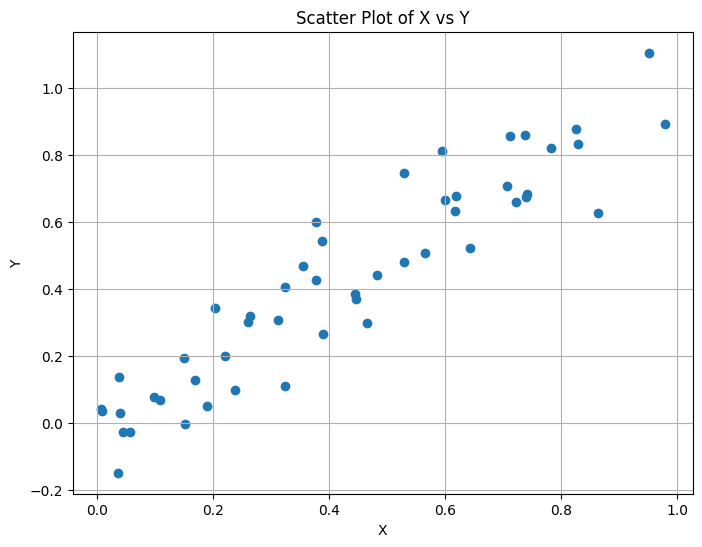

Correlation: 0.9531324630942766
Built-in Correlation: 0.934069813832391


In [67]:
X = np.random.rand(50)
Y = X + np.random.normal(0, 0.1, 50)
plt.figure(figsize=(8, 6))
plt.scatter(X, Y)
plt.title("Scatter Plot of X vs Y")
plt.xlabel("X")
plt.ylabel("Y")
plt.grid()
plt.show()

print("Correlation: "+str(np.cov(X, Y)[0, 1] / (np.std(X) * np.std(Y))))
print("Built-in Correlation: "+str(np.corrcoef(X, Y)[0, 1]))

We can add a little more noise to the error term by increasing the standard deviation of the error term

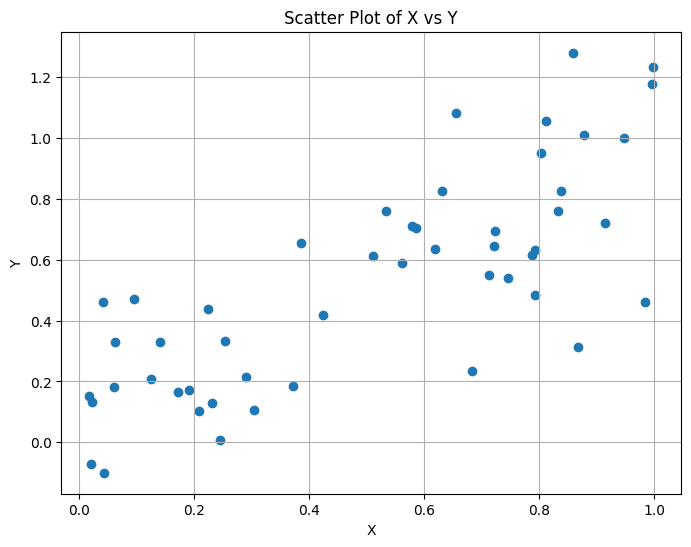

Correlation: 0.792070690082393
Built-in Correlation: 0.7762292762807451


In [68]:
X = np.random.rand(50)
Y = X + np.random.normal(0, 0.2, 50)
plt.figure(figsize=(8, 6))
plt.scatter(X, Y)
plt.title("Scatter Plot of X vs Y")
plt.xlabel("X")
plt.ylabel("Y")
plt.grid()
plt.show()

print("Correlation: "+str(np.cov(X, Y)[0, 1] / (np.std(X) * np.std(Y))))
print("Built-in Correlation: "+str(np.corrcoef(X, Y)[0, 1]))

Let us also visualise the case of a negative correlation (i.e inverse relationship)

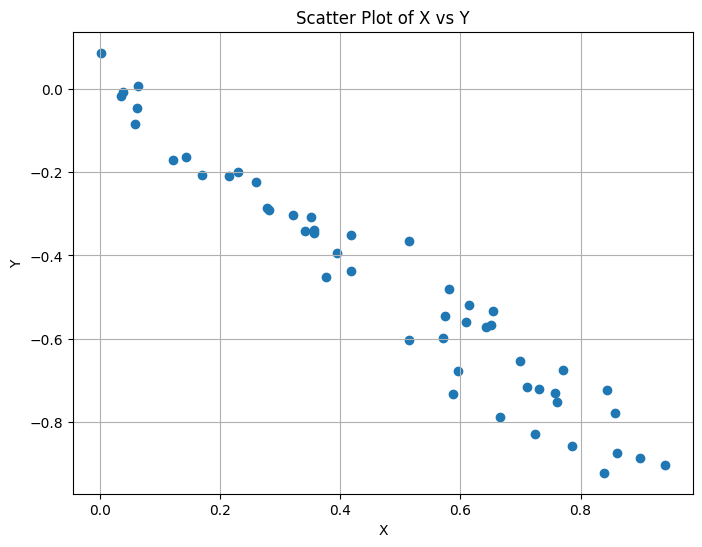

Correlation: -0.9916503513430804
Built-in Correlation: -0.9718173443162187


In [69]:
X = np.random.rand(50)
Y = -X + np.random.normal(0, 0.1, 50)
plt.figure(figsize=(8, 6))
plt.scatter(X, Y)
plt.title("Scatter Plot of X vs Y")
plt.xlabel("X")
plt.ylabel("Y")
plt.grid()
plt.show()

print("Correlation: "+str(np.cov(X, Y)[0, 1] / (np.std(X) * np.std(Y))))
print("Built-in Correlation: "+str(np.corrcoef(X, Y)[0, 1]))

Combining all 4 graphs

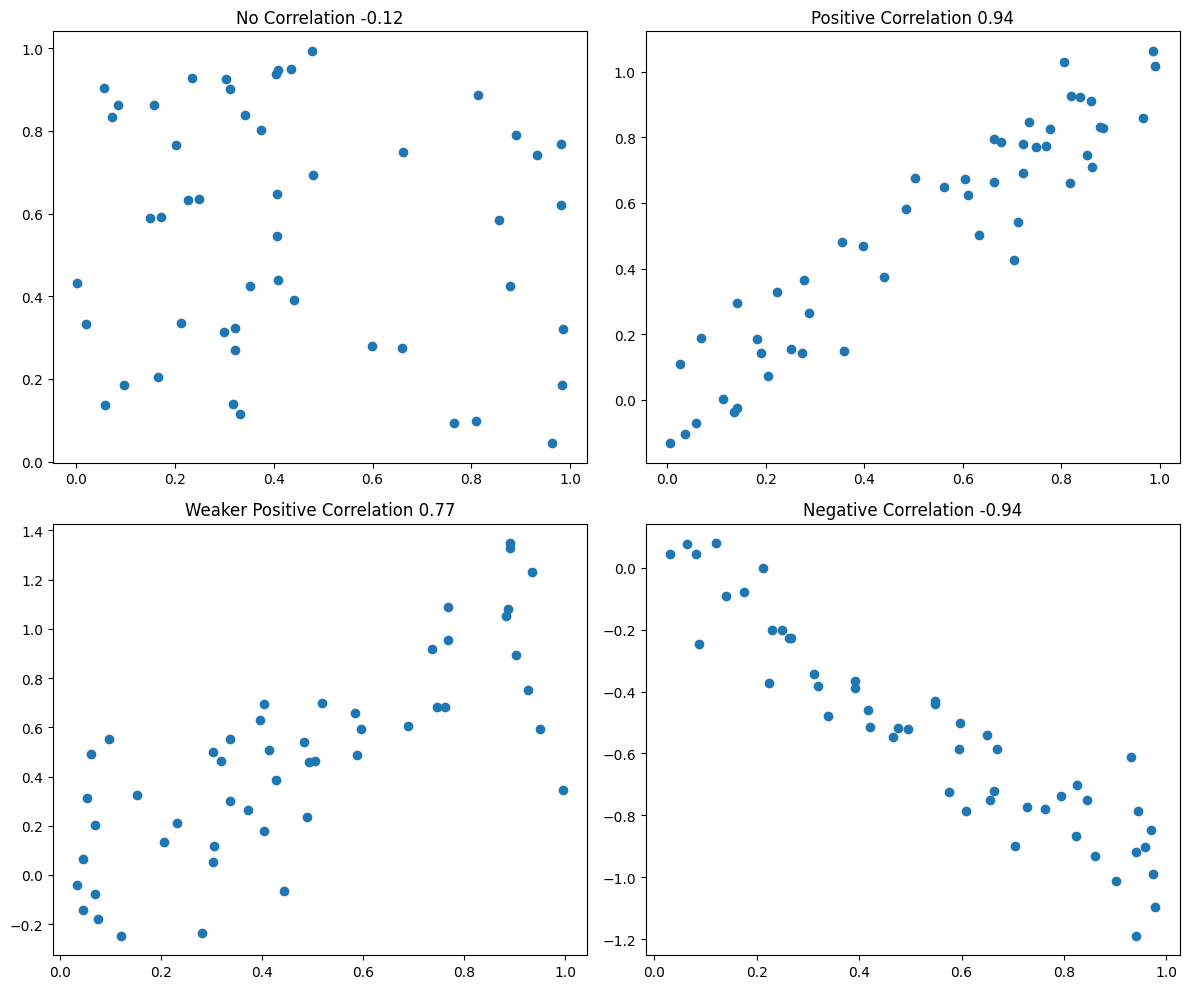

In [70]:
# Create 4 subplots
fig, axs = plt.subplots(2, 2, figsize=(12, 10))
# First subplot: No correlation
X = np.random.rand(50)
Y = np.random.rand(50)
axs[0, 0].scatter(X, Y)
axs[0, 0].set_title(f"No Correlation {np.corrcoef(X, Y)[0, 1]:.2f}")
# Second subplot: Positive correlation
X = np.random.rand(50)
Y = X + np.random.normal(0, 0.1, 50)
axs[0, 1].scatter(X, Y)
axs[0, 1].set_title(f"Positive Correlation {np.corrcoef(X, Y)[0, 1]:.2f}")
# Third subplot: Weaker positive correlation
X = np.random.rand(50)
Y = X + np.random.normal(0, 0.25, 50)
axs[1, 0].scatter(X, Y)
axs[1, 0].set_title(f"Weaker Positive Correlation {np.corrcoef(X, Y)[0, 1]:.2f}")
# Fourth subplot: Negative correlation
X = np.random.rand(50)
Y = -X + np.random.normal(0, 0.1, 50)
axs[1, 1].scatter(X, Y)
axs[1, 1].set_title(f"Negative Correlation {np.corrcoef(X, Y)[0, 1]:.2f}")
# Adjust layout and show the plot
plt.tight_layout()
plt.show()

#### How is this useful in finance?  
**Determining related assets (and potential predictive relationships)**

Once we have established that two time series (e.g., stock prices) are likely **related** (via correlation or other measures), we can leverage this relationship to attempt to **predict future values** of one series based on the other — or at least anticipate co-movements.

##### Real-world finance example: Apple (AAPL) and Lam Research (LRCX)

Consider the **stock price** of **Apple Inc.** (a major consumer electronics company) and **Lam Research Corporation** (a leading manufacturer of semiconductor manufacturing equipment).

- Apple relies heavily on advanced chips for its iPhones, Macs, iPads, etc.  
- Lam Research supplies critical **etching, deposition**, and other wafer fabrication tools used by chip foundries (e.g., TSMC, Intel) that produce those advanced semiconductors.  

When Apple ramps up production or launches products with cutting-edge chips → demand for semiconductor equipment often rises → Lam Research benefits (and vice versa during slowdowns).

This creates a **supply-chain linkage**: movements in Apple's business outlook / product demand can influence semiconductor equipment demand, leading to correlated stock price behavior.

##### Practical applications in finance

1. **Portfolio diversification / hedging**  
   Identify assets that tend to move together (high positive correlation) or in opposite directions (negative) to manage risk.

2. **Pairs trading / statistical arbitrage**  
   If two related stocks temporarily diverge from their historical relationship, trade on the expectation they will converge again.

3. **Predictive modeling / lead-lag analysis**  
   If one series (e.g., Apple orders or news) leads the other (Lam's equipment demand), use it for short-term forecasting or sentiment-based trading.

4. **Sector / thematic exposure**  
   Understanding these linkages helps investors gain indirect exposure to a company (e.g., bet on Apple's growth via upstream suppliers like Lam) without holding the primary stock.

**Bottom line**:  
Correlation analysis reveals **economic and supply-chain relationships** hidden in price data. In finance, spotting these can inform better trading, risk management, and investment decisions — especially in interconnected sectors like tech and semiconductors.

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


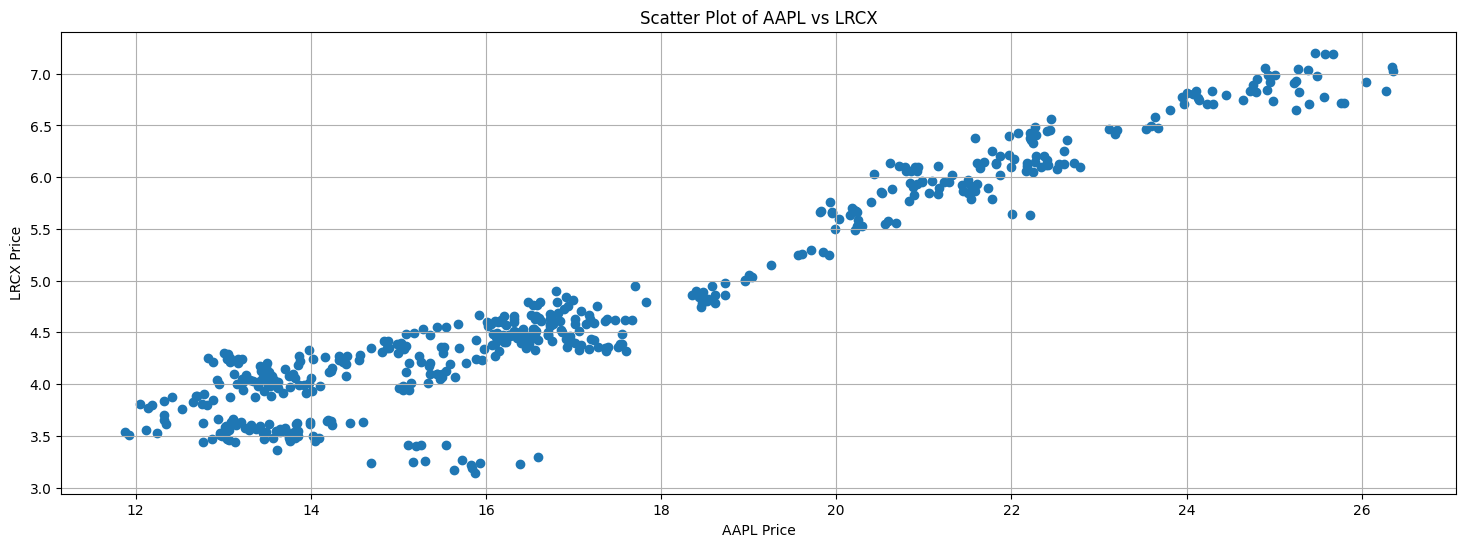

Correlation between AAPL and LRCX: 0.9595012366046637
Correlation between AAPL and S&P 500: 0.9007672706100713
Correlation between LRCX and S&P 500: 0.9339471065350853


In [71]:
# Pull the price for our two stocks as well as the S&P 500 index
start_date = "2013-01-01"
end_date = "2015-01-01"


benchmark = yf.download("^GSPC", start=start_date, end=end_date)["Close"]
aapl = yf.download("AAPL", start=start_date, end=end_date)["Close"]
lrcx = yf.download("LRCX", start=start_date, end=end_date)["Close"]

# Plot the two stocks
plt.figure(figsize=(18, 6))
plt.scatter(aapl, lrcx)
plt.title("Scatter Plot of AAPL vs LRCX")
plt.xlabel("AAPL Price")
plt.ylabel("LRCX Price")
plt.grid()
plt.show()

print("Correlation between AAPL and LRCX:", np.corrcoef(aapl['AAPL'], lrcx['LRCX'])[0, 1])
print("Correlation between AAPL and S&P 500:", np.corrcoef(aapl['AAPL'], benchmark['^GSPC'])[0, 1])
print("Correlation between LRCX and S&P 500:", np.corrcoef(lrcx['LRCX'], benchmark['^GSPC'])[0, 1])

Remarks:

---

The correlation figures indicate very strong positive linear relationships among the three assets:
- AAPL and LRCX: 0.96
- AAPL and S&P 500: 0.90
- LRCX and S&P 500: 0.93

At first glance, this suggests that Apple Inc. (AAPL) and Lam Research Corporation (LRCX) tend to move very closely together, and both move closely with the broader market represented by the S&P 500. However, it is critical to emphasize that correlation does not imply causation. A high correlation between AAPL and LRCX does not mean that one explains or drives the other. Their co-movement could simply be due to:
1. Common exposure to market risk (systematic risk)
> Since both stocks are highly correlated with the S&P 500, it raises the possibility that overall market movements are the dominant factor influencing both. In other words, they may be reacting to the same macroeconomic forces, liquidity conditions, or investor sentiment.
2. Sector or industry effects
> Both companies operate within the broader technology and semiconductor ecosystem. A macro event impacting tech demand (e.g., interest rates, AI investment cycles, global supply chains) could push both stocks in the same direction without either company directly influencing the other.
3. Index weighting dynamics
> AAPL has a large weight in the S&P 500. This introduces an additional question:

Is the market driving AAPL? Or is AAPL, due to its size, materially influencing the index itself? Or are both reacting simultaneously to macro news? The correlation values alone cannot answer these questions.

#### Limitations of (simple / point-estimate) Correlation

**Significance testing is tricky in practice**  
It is difficult to rigorously determine whether a correlation is **statistically significant**, especially when the data (e.g., stock returns) are **not normally distributed** — which is very common in financial time series.  

Standard significance tests for Pearson's r assume normality and independence. Violations can lead to unreliable p-values (inflated Type I error or reduced power).

**Example observation — AAPL and LRCX**  
The (overall) correlation coefficient between AAPL and LRCX stock prices is **close to 1** (very high). This suggests the two stocks are strongly positively correlated over the period examined.  

However, both stocks also show **high correlation with the broader market** (e.g., S&P 500). So the high AAPL–LRCX correlation might partly reflect **common market exposure** rather than a unique pairwise relationship.

**One fundamental problem with point estimates**  
A single correlation calculated over an arbitrary historical window can be misleading. It depends heavily on the chosen time period and can vary substantially.

**Better approach**  
- Compute correlations over **many rolling windows** (or different sub-periods)  
- Examine the **distribution** of these rolling correlation values  
- This gives a more robust picture of how stable / variable the relationship is  

More details on why single-point historical estimates can be problematic (and how to address them) will be covered in future notebooks.

**Illustrative example**  
As an example, the overall correlation between AAPL and LRCX from **2013-01-01 to 2015-01-01** was approximately **0.95** (very strong).  

But let's look at a **rolling 60-day correlation** over the same period to see how the relationship **varies over time**:

- The rolling value fluctuates — sometimes lower, sometimes near 1  
- This shows the relationship is strong but **not perfectly constant**  
- Rolling windows reveal periods of weaker linkage that a single full-period number hides

**Key takeaway**  
High point correlations look impressive, but always check **stability over time** (via rolling correlations) and consider **market-wide factors** before concluding two assets have a special economic link.

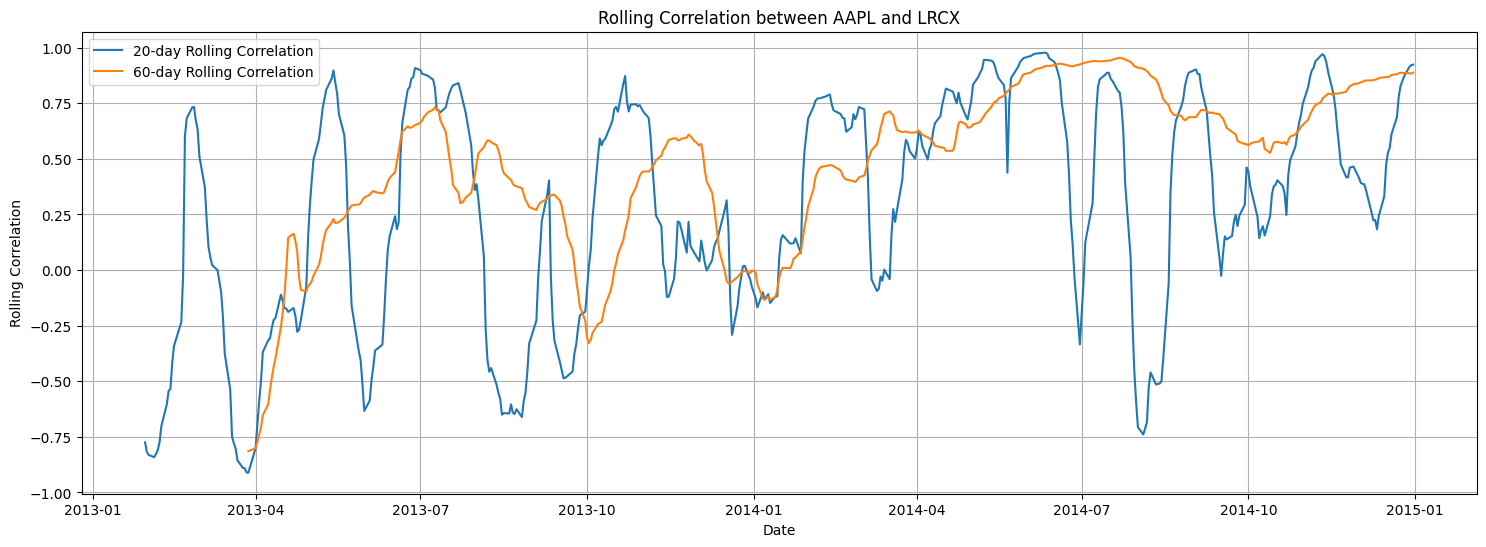

In [72]:
# Define a rolling window of 20 and 60 days and calculate the rolling correlation between AAPL and LRCX
rolling_correlation_20 = aapl['AAPL'].rolling(window=20).corr(lrcx['LRCX'])
rolling_correlation_60 = aapl['AAPL'].rolling(window=60).corr(lrcx['LRCX'])

plt.figure(figsize=(18, 6))
plt.plot(rolling_correlation_20, label="20-day Rolling Correlation")
plt.plot(rolling_correlation_60, label="60-day Rolling Correlation")
plt.title("Rolling Correlation between AAPL and LRCX")
plt.xlabel("Date")
plt.ylabel("Rolling Correlation")
plt.grid()
plt.legend()
plt.show()

Remarks:

---

A static correlation (like 0.96 between AAPL and LRCX) gives you one single summary number over the entire sample period. It assumes the relationship is stable and constant. But in financial markets, relationships are rarely constant.

For instance, a static value might say “strongly correlated,” but rolling correlation (as shown in the above chart) might reveal:
- Correlation spikes during crises
- Correlation drops during sector-specific events
- Temporary decoupling phases

#### Non-Linear Relationships & Limitations of Pearson Correlation

The **Pearson correlation coefficient** only measures the **strength and direction of linear relationships** between two variables. If the true relationship is **non-linear**, Pearson's r can be misleading — it may be low (close to 0) even when the variables are strongly associated in a predictable (but curved or delayed) way.

##### Important reminders & common pitfalls

- Two variables can be strongly related without being **linearly** related.  
  Examples include:
  - Quadratic relationships (U-shaped or inverted-U)
  - Exponential or logarithmic patterns
  - Periodic / sinusoidal relationships

- **Lagged relationships**  
  One variable might closely follow another, **but with a time delay** (e.g., interest rates today affect housing starts 6–12 months later).  
  Pearson correlation on raw (unlagged) series will miss this.  
  → Solution: Use **cross-correlation** or **lagged correlation** functions to detect leads/lags.

- **Sensitivity to outliers**  
  Pearson's r is **very sensitive** to extreme values.  
  A few outliers can dramatically inflate or deflate the coefficient, even if the bulk of the data shows little relationship.  
  → Always visualize the scatter plot first.  
  → Consider robust alternatives (e.g., Spearman's rank correlation, trimmed estimators) when outliers are suspected.

- **Noise vs. signal**  
  It is not always obvious whether unusual data points represent:
  - Meaningful information (rare but real events)
  - Or simply **noise** / measurement error  
  Including or excluding them can substantially change the correlation.

##### Practical demonstration idea

As an illustrative example, let's generate synthetic data where:
- The underlying relationship is **non-linear** (e.g., quadratic or exponential)
- The noise follows a **Poisson distribution** (instead of normal/Gaussian), which is common in count data, financial volumes, or arrival processes

We will compute Pearson's r and see how poorly it captures the association compared to a scatter plot or rank-based measure.

**Key takeaway**  

Correlation ≠ causation, and more importantly:   **low correlation does NOT imply no relationship** — it only means **no strong linear relationship**.   Always complement Pearson correlation with:
- Scatter plots
- Non-parametric measures (Spearman, Kendall)
- Visual inspection for curvature, clusters, or lags
- Domain knowledge about possible non-linear / delayed mechanisms

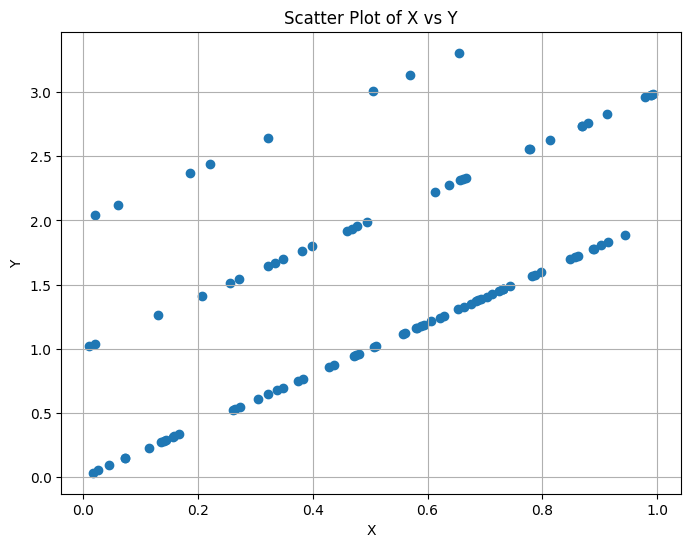

Correlation between X and Y: 0.6206402802379308


In [73]:
X = np.random.rand(100)
Y = 2 * X + np.random.poisson(0.5, size=100)

# Plot the data
plt.figure(figsize=(8, 6))
plt.scatter(X, Y)
plt.title("Scatter Plot of X vs Y")
plt.xlabel("X")
plt.ylabel("Y")
plt.grid()
plt.show()

# Calculate and print the correlation coefficient
print("Correlation between X and Y:", np.corrcoef(X, Y)[0, 1])

Looking at the above examole, we see that the computed correlation coefficient of 0.56 implies a weak linear relationship. But on further inspection, we see from the visualisation that there is clearly a predictive model that can be be derived between X and Y. This simply arises becauses correlation coefficient assumes normality and a linear model, and when we violate those conditions, it will not do as well as one would hope. 

This is where the **Spearman Rank Correlation Coefficient** comes in.

#### Spearman's Rank Correlation Coefficient  

*Measuring monotonic (not necessarily linear) relationships*


##### What is Spearman's rank correlation?

Spearman's **ρ** (rho) assesses whether two variables tend to **move together in the same (or opposite) direction**, i.e., whether the relationship is **monotonic** — but **not** necessarily linear.

- When one variable increases, the other tends to increase (positive monotonic)  
- When one variable increases, the other tends to decrease (negative monotonic)

Unlike Pearson's r, Spearman's ρ does **not** assume a straight-line relationship.   It only cares about the **ordering / ranking** of the observations.

##### How it works (conceptually)

Instead of using the raw data values, we:

1. Convert each variable to its **ranks** (1 = lowest value, 2 = next lowest, etc.)  
   → Handles different units and non-linear scaling automatically  
2. Compute Pearson's correlation **on the ranks** (or equivalently, use the dedicated formula)

**Formula** (most common form):

$$
\rho = 1 - \frac{6 \sum_{i=1}^{n} d_i^2}{n(n^2 - 1)}
$$

Where:
- $d_i$ = difference between the ranks of the $i$-th pair of observations  
- $n$ = number of observations  
- Ties are usually handled by assigning average ranks

(Alternative: just apply Pearson correlation directly to the ranked data — gives the same result when there are no ties.)

##### When is Spearman's ρ especially useful?

- Data come in **different units** or **different scales** (e.g., land price vs. plot size)  
- The relationship looks **monotonic but curved** (e.g., $y = x^2$, $y = \log(x)$, $y = e^x$)  
- Data violate Pearson's assumptions:  
  - Not normally distributed  
  - Presence of **outliers** (ranks are robust to extremes)  
  - Ordinal or non-interval data  
- You suspect a consistent directional trend, but linearity is doubtful

##### Real-world example

Consider land prices and plot size:  
- Larger plots tend to be more expensive, but the relationship is often **non-linear** (price per square foot usually decreases as size increases).   Spearman's ρ will still capture the strong monotonic association even when Pearson's r is reduced by the curvature.

**Key advantage over Pearson**  
Spearman is **more general** — it detects any monotonic trend, linear or not, and is **robust** to outliers and non-normality.

**Bottom line**  
Use Spearman's rank correlation when you care about **consistent directional movement** rather than strict linearity, or when the data don't meet Pearson's assumptions.

Consider a simple example of the Spearman Rank

In [74]:
lst = [ 10, 9, 5, 7 ,5]
print("Raw Data: \n", lst)
print("Ranking: \n", stats.rankdata(lst, method='average'))

Raw Data: 
 [10, 9, 5, 7, 5]
Ranking: 
 [5.  4.  1.5 3.  1.5]


#### Spearman's Rank Correlation Coefficient (ρ)  
**Intuition & Definition**

##### Intuition  
Instead of measuring how the **raw values** of two variables X and Y relate to each other, Spearman's rank correlation looks at the **relationship between their ranks** (ordered positions). This makes it:
- **Robust to outliers** — extreme values only affect their rank position, not the overall pattern dramatically  
- **Invariant to monotonic transformations** of the data (scaling, shifting, exponentiation, logarithms, etc.)  
- Suitable when the relationship is **monotonic** (consistently increasing or decreasing), even if it is **not linear**

##### Definition & Formula

To compute Spearman's rank correlation coefficient (ρ or rs) between two datasets X and Y (each of size n):
1. Rank the observations in X and in Y separately (lowest value → rank 1, next → rank 2, etc.)  
2. For **ties**, assign the **average rank** of the positions they would occupy  
   Example: Values 10, 12, 12, 15 → ranks 1, 2.5, 2.5, 4
3. Calculate the differences in ranks for each paired observation:  
   dᵢ = rank(Xᵢ) − rank(Yᵢ)
4. Apply the formula:

$$
r_s = 1 - \frac{6 \sum_{i=1}^{n} d_i^2}{n(n^2 - 1)}
$$

Where:
- dᵢ = difference between the ranks of the i-th pair  
- n = number of observations  
- The summation is over all pairs

##### Interpretation

- **Range**: rs is always between **−1** and **+1**  
  - **+1** → perfect positive monotonic relationship (ranks are identical)  
  - **−1** → perfect negative (inverse) monotonic relationship  
  - **0** → no monotonic relationship (ranks are unrelated)

- **Important note**: A value close to **0** does **not** mean there is no relationship at all — it only means there is **no monotonic** relationship.  
  Example:
  If Y = X but **shifted by a constant delay** (e.g., Yₜ = Xₜ₋₂), the variables may be strongly related in a lagged sense, but Spearman's ρ on the raw paired data will be close to zero because the ranks do not align monotonically without accounting for the lag.

**Bottom line**  
Spearman's rank correlation is a powerful, non-parametric alternative to Pearson when:
- You suspect non-linearity but consistent direction  
- Data contain outliers  
- Variables are on very different scales  
- Normality or linearity assumptions are violated

Use it whenever monotonic association (rather than strict linear) is what matters.

#### Experiment: Outliers & Non-Normal Noise – Pearson vs Spearman

##### Goal of the experiment  
Show how **outliers** and **non-normal distributions** (e.g., Poisson) can mislead **Pearson's** correlation while **Spearman's rank correlation** remains more robust.

##### Setup

1. Draw independent values of **X** from a **Poisson distribution** (highly skewed, non-normal, produces many small values + occasional large ones = natural outliers)  
2. Set **Y = e^X + ε**, where ε is drawn from **another independent Poisson distribution**  
   → This creates a strong **exponential (monotonic but highly non-linear)** relationship between X and Y

3. Because of the exponential transformation, large values of X produce **extremely large** values of Y → severe right-skew and huge outliers

##### What we expect

- **Pearson's r** (linear correlation)  
  - Gets **heavily distorted** by the large outlier pairs (very high X → extremely high Y)  
  - The coefficient is pulled toward the direction of the outliers but often ends up **much lower** than the true underlying monotonic strength  
  - On average, Pearson **underestimates** the strength of the relationship due to outlier confusion

- **Spearman's ρ** (rank correlation)  
  - Works on **ranks**, so extreme values are simply assigned the highest ranks — they don’t disproportionately influence the result  
  - Much more robust to the exponential blow-up and Poisson-induced outliers  
  - Should reveal a **much stronger monotonic association** (close to +1 in many realizations)

##### Key insight from this experiment

- When data have **heavy tails**, **outliers**, or **non-linear monotonic** patterns (like exponential growth),  
  **Pearson's correlation** can be **severely biased downward** and misleading.

- **Spearman's rank correlation** **compresses** the effect of outliers by focusing only on order → it better detects the **true monotonic relationship** even when linearity is absent and noise/outliers are extreme.

##### Takeaway

Use **Spearman** (or other rank-based methods) whenever:
- Data are clearly **non-normal** (e.g., counts, financial volumes, exponential growth)
- You suspect **outliers** or **extreme values**
- The relationship looks **monotonic** but not necessarily linear
- You want a more **robust** measure of directional association

In contrast, Pearson is optimal only when the relationship is roughly **linear**, residuals are roughly **normal/homoscedastic**, and outliers are absent or already handled.

**Next step (in code)**  
We can simulate this many times (e.g., 1000 runs), compute both coefficients each time, and compare their distributions to see how often & how badly Pearson fails compared to Spearman.

In [75]:
n = 100

def compare_correlation_and_spearman_ranl(n):
  X = np.random.poisson(5, size=n)
  Y = np.exp(X)+ np.random.poisson(0.5, size=n)
  Xrank = stats.rankdata(X, method='average')
  Yrank = stats.rankdata(Y, method='average')
  
  diff = Xrank - Yrank
  r_s = 1 - (6 * np.sum(diff**2)) / (n * (n**2 - 1))
  r_c = np.corrcoef(X, Y)[0, 1]
  return r_s, r_c

experiments = 1000
spearman_coefficients = np.ndarray(experiments)
correlation_coefficients = np.ndarray(experiments)

for i in range(experiments):
  r_s, r_c = compare_correlation_and_spearman_ranl(n)
  spearman_coefficients[i] = r_s
  correlation_coefficients[i] = r_c
  
print("Spearman Coefficients: ", np.mean(spearman_coefficients))
print("Correlation Coefficients: ", np.mean(correlation_coefficients))

Spearman Coefficients:  0.9920720132013202
Correlation Coefficients:  0.5262068016752498


We can also visualise this in the form of a histogram chart

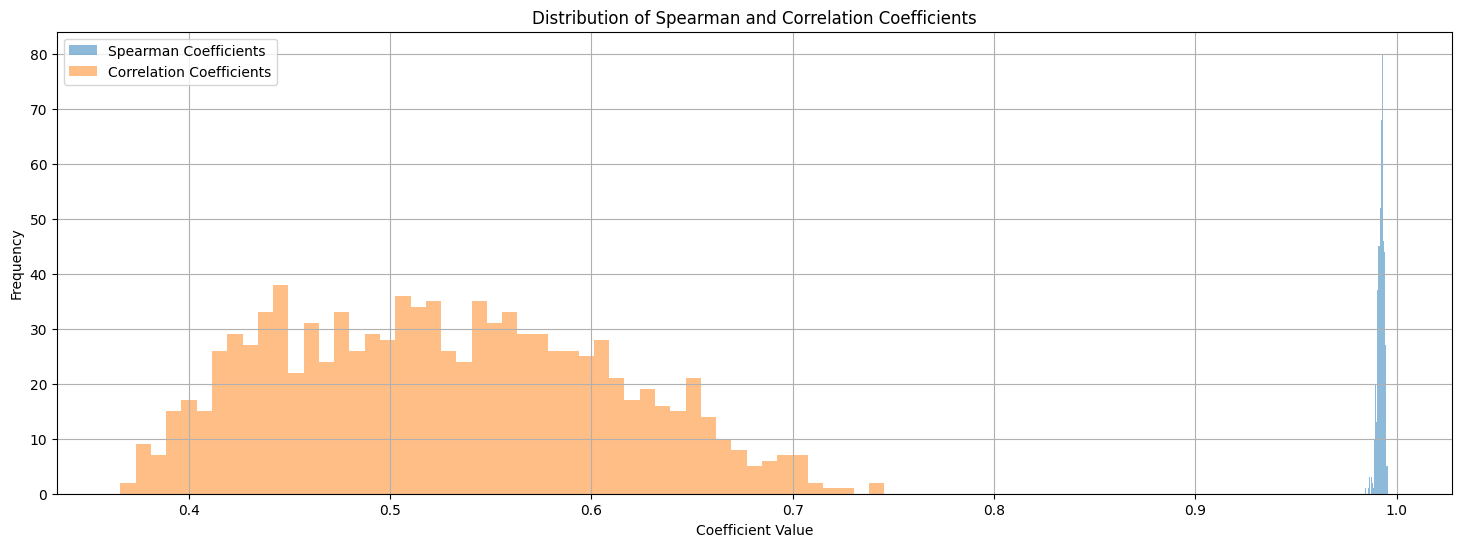

In [76]:
plt.figure(figsize=(18, 6))
plt.hist(spearman_coefficients, bins=50, alpha=0.5, label='Spearman Coefficients')
plt.hist(correlation_coefficients, bins=50, alpha=0.5, label='Correlation Coefficients')
plt.title("Distribution of Spearman and Correlation Coefficients")
plt.xlabel("Coefficient Value")
plt.ylabel("Frequency")
plt.legend()
plt.grid()
plt.show()

We can visualise the time plot of X and Y in the following chart.

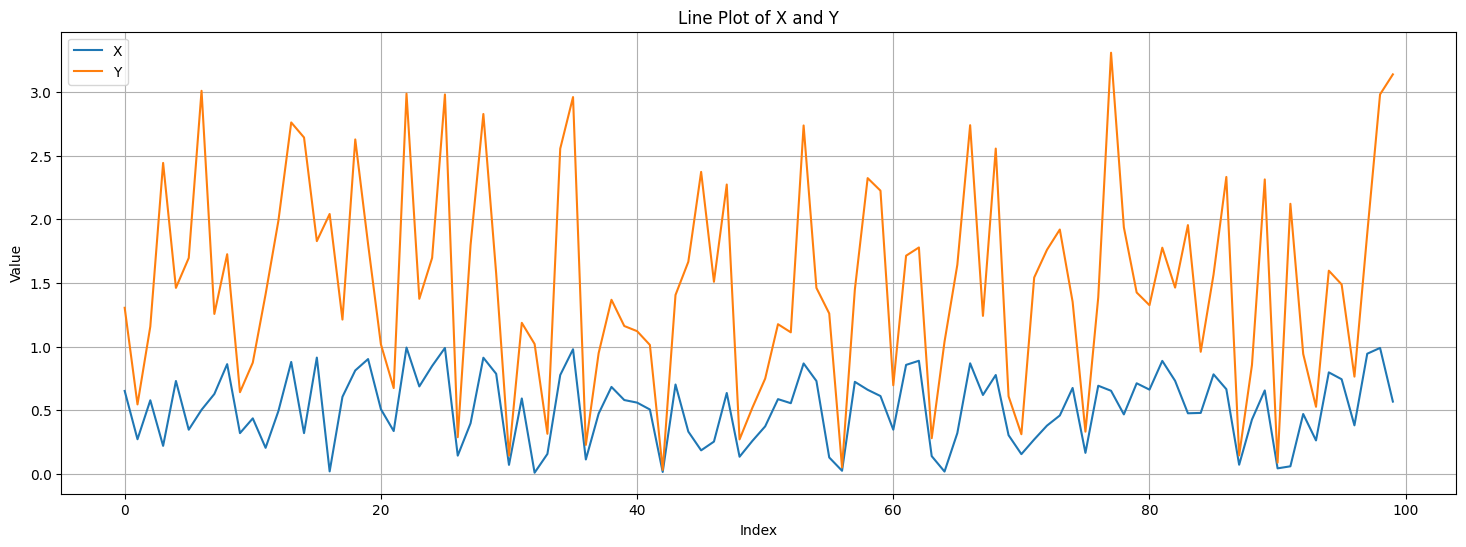

In [79]:
plt.figure(figsize=(18, 6))
plt.plot(X)
plt.plot(Y)
plt.title("Line Plot of X and Y")
plt.xlabel("Index")
plt.ylabel("Value")
plt.grid()
plt.legend(["X", "Y"])
plt.show()

#### Delay in Correlation

Often times, you might have the case where one process affects another, but after a time lag. Let us see what happens if we add the delay to it.

In [ ]:
n = 100

X = np.random.rand(n)
Xrank = stats.rankdata(X, method='average')
# The lag of 2 here: (n-2) because we are adding 2 values to the front of the list
Yrank = stats.rankdata([1, 1] + list(X[:(n-2)]), method='average')

diffs = Xrank - Yrank
r_s = 1 - (6 * np.sum(diffs**2)) / (n * (n**2 - 1))
print("Spearman Rank Correlation Coefficient:", r_s)

Spearman Rank Correlation Coefficient: 0.14917791779177914


True enough, when we add the lag / delay to the data, our Spearman Rank correlation coefficient drops. Therefore, it is important that we use both regular and spearman rank correlation to check for lagged relationships by offsetting your data and testing for different offset values.

**Using the in-built function in Scipy Stats**

In [85]:
np.random.seed(0)

n = 100
X = np.random.rand(n)
Y = np.random.rand(n)

r_s = stats.spearmanr(X, Y)
print("Spearman Rank Correlation Coefficient (using scipy):", r_s[0])
print("p-value (using scipy):", r_s[1])

Spearman Rank Correlation Coefficient (using scipy): -0.0627062706270627
p-value (using scipy): 0.535396469432264


Remarks:

---

We now have ourselves an $r_s$, but how do we interpret it? It is negative, so we know that the variables are anticorrelated. It is not very large, so we know they are not perfectly negatively correlated, but it is hard to say from a glance just how significant the correlation is. Luckily, Spearman r also computes the p-value for this coefficient and sample size for us. We can see that the p-value here is above $0.05$; therefore, we cannot claim that X and Y are correlated.

#### Real-World Example: Mutual Fund Expense Ratio vs. 3-Year Sharpe Ratio

Now that we have seen how **Spearman's rank correlation** works in theory, let us apply it to real financial data.

##### Question we want to explore

**Does a mutual fund's expense ratio predict (or correlate with) its risk-adjusted performance?**  
Specifically: Is a **higher expense ratio** (more spending on administration, management fees, marketing, etc.) associated with:

- **Lower** risk-adjusted returns (e.g., worse 3-year Sharpe ratio)?  
  → Intuition: higher fees eat into returns → lower Sharpe  
- Or perhaps **higher** Sharpe (if active management justifies the cost)?  
- Or no meaningful relationship at all?

In other words: Does spending more on fund management **lower risk or increase returns** enough to offset the fees, or does it mostly drag performance down?


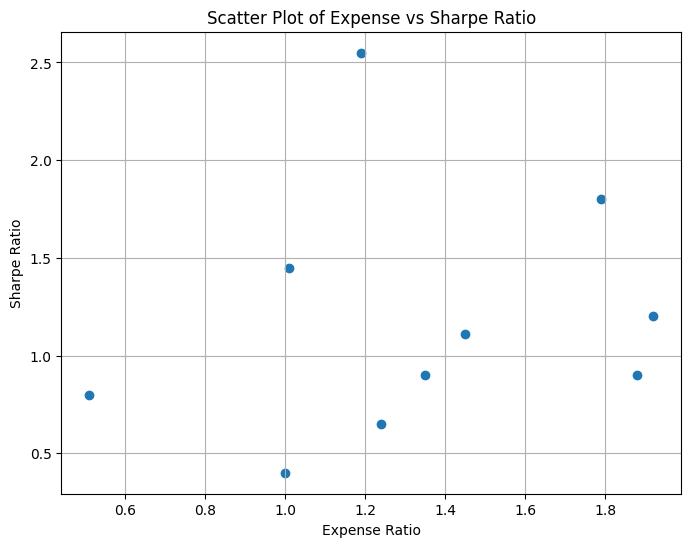

Spearman Rank Correlation Coefficient (using scipy): 0.3404271044608362
p-value (using scipy): 0.3357822630985314


In [86]:
expense = [1.35, 1.79, 1.45, 1.88, 1, 1.01, 1.19, 1.92, 0.51, 1.24]
sharpe = [0.9, 1.8, 1.11, 0.9, 0.4, 1.45, 2.55, 1.2, 0.8, 0.65]

plt.figure(figsize=(8, 6))
plt.scatter(expense, sharpe)
plt.title("Scatter Plot of Expense vs Sharpe Ratio")
plt.xlabel("Expense Ratio")
plt.ylabel("Sharpe Ratio")
plt.grid()
plt.show()

r_s = stats.spearmanr(expense, sharpe)
print("Spearman Rank Correlation Coefficient (using scipy):", r_s[0])
print("p-value (using scipy):", r_s[1])


#### Real Word Case: Evaluating a Ranking Model

Let's say that we have some way of ranking securities and that we would like to test how well our ranking performs in practice. In this case our model just takes the mean daily return for the last month and ranks the stocks by that metric. We hypothesize that this will be predictive of the mean returns over the next month. To test this we score the stocks based on a lookback window, then take the Spearman rank correlation of the score and the mean returns over the walk forward month.

[*********************100%***********************]  20 of 20 completed
[*********************100%***********************]  20 of 20 completed


          Scores  Walk Forward Returns
Ticker                                
AAPL    0.003868              0.001359
ADBE    0.002106             -0.002963
AMZN    0.000617              0.000478
BAC     0.003007             -0.000458
CMCSA   0.001314             -0.000530
DIS     0.009691             -0.002886
GOOGL  -0.001099              0.003408
HD     -0.001631              0.001559
JPM     0.002919              0.001783
MA      0.002575             -0.005564
META   -0.002187             -0.001957
MSFT    0.001399              0.003683
NFLX    0.003467              0.002005
NVDA   -0.001114             -0.000147
PG     -0.000056             -0.003600
TSLA    0.009691              0.005440
UNH     0.001521             -0.002462
V       0.001730             -0.006491
VZ     -0.001428             -0.003349
WMT    -0.002529             -0.002276


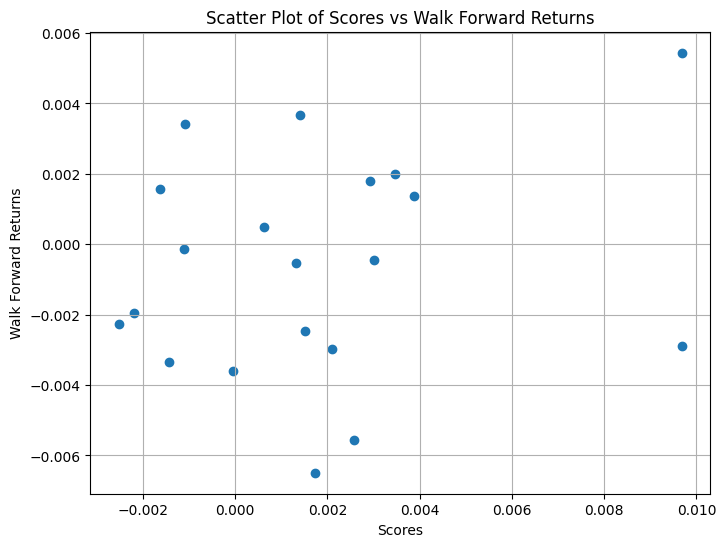

Spearman Rank Correlation Coefficient (using scipy): 0.1413533834586466
p-value (using scipy): 0.5522144386322418


In [94]:
tickers = ["AAPL", "MSFT", "GOOGL", "AMZN", "META", "TSLA", "NVDA", "JPM", "V", "DIS", "BAC", "WMT", "PG", "MA", "HD", "UNH", "VZ", "ADBE", "CMCSA", "NFLX"]

start = "2020-12-01"
end = "2021-01-01"

historical_returns = yf.download(tickers, start=start, end=end)["Close"].pct_change().dropna()

# Compute our stock scores
scores = np.mean(historical_returns, axis=0)

new_start = "2021-01-01"
new_end = "2021-02-01"
walk_forward_returns = yf.download(tickers, start=new_start, end=new_end)["Close"].pct_change().dropna()
walk_forward_returns = walk_forward_returns.mean()

df = pd.DataFrame({"Scores": scores, "Walk Forward Returns": walk_forward_returns})
print(df)

plt.figure(figsize=(8, 6))
plt.scatter(scores, walk_forward_returns)
plt.title("Scatter Plot of Scores vs Walk Forward Returns")
plt.xlabel("Scores")
plt.ylabel("Walk Forward Returns")
plt.grid()
plt.show()

# Compute the Spearman rank correlation coefficient
r_s = stats.spearmanr(scores, walk_forward_returns)
print("Spearman Rank Correlation Coefficient (using scipy):", r_s[0])
print("p-value (using scipy):", r_s[1])

Remarks:

---

In the above example, we created a long-short equity strategy, where we ranked our stocks based on the mean of their historical returns ```scores = np.mean(historical_returns, axis=0)```. Now we want to check if our ranking system is meaningful and we do so by checking the forward returns (i,e the next months data) and compute their scores for the next month. What we hope to validate or conclude is whether the stocks we ranked high (i.e the top N on our ranking model) on the initial start and end date data, should in general, have higher returns in the following month.

What we did was we generated a scatter plot of the scores for the first and subsequent month returns. Then we ran a spearman rank correlation test to see if the returns for the previous months were predictive of the returns for the next month. This test is to validate whether our ranking method works from a statistically significant perspective. 

But as we can see, our p-value is 0.55, which is way above 0.05. So we do not reject the null hypothesis, and thus, we conclude that the ranking does not produce anything meaningful. So the conclusion from this test here is to show us that *Momentum style strategies* - like the cross-sectional returns ranking long-short method - DO NOT work in this monthly timeframe during that specific time period.